In [1]:
!pip3 install -q --upgrade pip
!pip3 install -q pandas numpy matplotlib seaborn openpyxl climateserv requests netCDF4 xarray pyproj

In [3]:
import netCDF4 as nc
import numpy as np

def analyze_nasadem_file(file_path: str) -> None:
    """
    Analyze a NASADEM NetCDF file and print out its contents, such as variable names,
    dimensions, and min/max values for longitude and latitude.

    Args:
    file_path (str): The path to the NASADEM NetCDF file.
    """
    # Open the NetCDF file
    dataset = nc.Dataset(file_path, 'r')

    # Print general information about the file
    print('')
    print(f"Analyzing file: {file_path}")
    print("Variables in this file:")
    for var in dataset.variables:
        print(f" - {var}: {dataset.variables[var].dimensions}, {dataset.variables[var].shape}")

    # Check for common variables like longitude and latitude
    if 'lon' in dataset.variables and 'lat' in dataset.variables:
        lon = dataset.variables['lon'][:]
        lat = dataset.variables['lat'][:]
        print(f"Longitude range: {np.min(lon)} to {np.max(lon)}")
        print(f"Latitude range: {np.min(lat)} to {np.max(lat)}")
    
    # Close the dataset
    dataset.close()

# Paths to your files
file_paths = [
    'original_data/nasadem/NASADEM_NC.001_30m_aid0001.nc',
    'original_data/nasadem/NASADEM_NUMNC.001_30m_aid0001.nc'
]

# Analyze each file
for path in file_paths:
    analyze_nasadem_file(file_path=path)



Analyzing file: data/nasadem/NASADEM_NC.001_30m_aid0001.nc
Variables in this file:
 - crs: (), ()
 - time: ('time',), (1,)
 - lat: ('lat',), (2872,)
 - lon: ('lon',), (11915,)
 - NASADEM_HGT: ('time', 'lat', 'lon'), (1, 2872, 11915)
Longitude range: -17.078611111124776 to -13.769166666677682
Latitude range: 13.077222222232685 to 13.874722222233322

Analyzing file: data/nasadem/NASADEM_NUMNC.001_30m_aid0001.nc
Variables in this file:
 - crs: (), ()
 - time: ('time',), (1,)
 - lat: ('lat',), (2872,)
 - lon: ('lon',), (11915,)
 - NASADEM_NUM: ('time', 'lat', 'lon'), (1, 2872, 11915)
Longitude range: -17.078611111124776 to -13.769166666677682
Latitude range: 13.077222222232685 to 13.874722222233322


In [7]:
import xarray as xr
import pandas as pd

def load_nasadem_data_to_dataframe(file_path: str) -> pd.DataFrame:
    """
    Loads NASADEM data from a NetCDF file, removes the 'time' column, 
    drops rows with NaN in 'NASADEM_HGT', and converts it to a Pandas DataFrame.

    Args:
        file_path (str): Path to the NetCDF file.

    Returns:
        pd.DataFrame: DataFrame containing the data with the modifications applied.
    """
    # Open the NetCDF file
    ds = xr.open_dataset(file_path)

    # Select the 'NASADEM_HGT' variable and the first time point
    data = ds['NASADEM_HGT'].isel(time=0)

    # Convert to DataFrame
    df = data.to_dataframe().reset_index()

    # Drop the 'time' column
    df = df.drop(columns=['time'])

    # Drop rows where 'NASADEM_HGT' is NaN
    df = df.dropna(subset=['NASADEM_HGT'])

    return df

# Example usage
file_path = 'original_data/nasadem/NASADEM_NC.001_30m_aid0001.nc'
df = load_nasadem_data_to_dataframe(file_path=file_path)
df



,lat,lon,NASADEM_HGT
283,13.874722,-17.000000,0.0
284,13.874722,-16.999722,0.0
285,13.874722,-16.999444,0.0
286,13.874722,-16.999167,0.0
287,13.874722,-16.998889,0.0
...,...,...,...
34219875,13.077222,-13.770278,66.0
34219876,13.077222,-13.770000,65.0
34219877,13.077222,-13.769722,65.0
34219878,13.077222,-13.769444,64.0


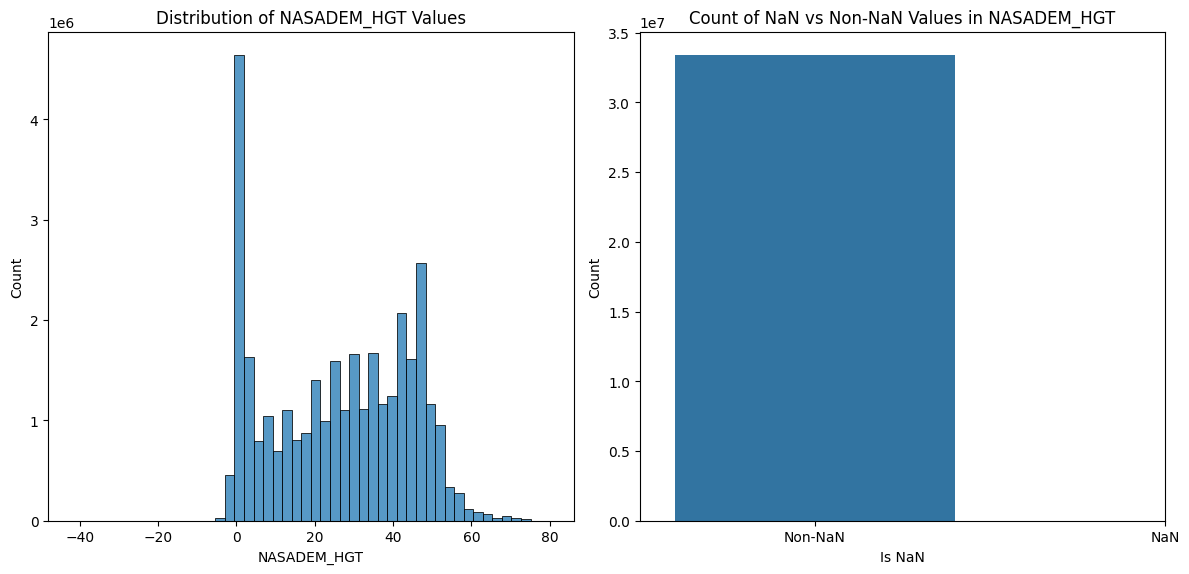

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_nasadem_hgt_distribution(df):
    """
    Plots the distribution of NASADEM_HGT values in the DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing NASADEM_HGT values.
    """
    # Set up the matplotlib figure
    plt.figure(figsize=(12, 6))

    # Histogram of NASADEM_HGT values excluding NaNs
    plt.subplot(1, 2, 1)
    sns.histplot(df['NASADEM_HGT'].dropna(), kde=False, bins=50)
    plt.title('Distribution of NASADEM_HGT Values')
    plt.xlabel('NASADEM_HGT')
    plt.ylabel('Count')

    # Count plot of NaN vs non-NaN values
    plt.subplot(1, 2, 2)
    nan_counts = df['NASADEM_HGT'].isna().value_counts()
    sns.barplot(x=nan_counts.index, y=nan_counts.values)
    plt.title('Count of NaN vs Non-NaN Values in NASADEM_HGT')
    plt.xlabel('Is NaN')
    plt.ylabel('Count')
    plt.xticks([0, 1], ['Non-NaN', 'NaN'])

    plt.tight_layout()
    plt.show()

# Call the function with your DataFrame
plot_nasadem_hgt_distribution(df)
